In [1]:
import os
import sys
import ast
base_directory = os.path.dirname(os.path.abspath(""))
sys.path.append(base_directory)

from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from radiology_dataset_db.db_validation import compare_dbs, verified_unverified_report, mean_sequence_matcher_in_column, identical_numbers_in_column, mean_jaccard_in_column

In [2]:
def plot_histogram(df, xcol, xlabel=None, ylabel=None, title=None, logx=False, logy=False, xmin=0, bins=20, integer_ticks=True, output_path=None):
    num_na = df[xcol].isna().sum()
    print(f"Column '{xcol}' has {num_na} / {len(df)} null entries.")
    
    data = df[xcol].dropna()

    plt.figure(figsize=(10, 6))
    if logx:
        data = data[data > 0]  # remove non-positive values
        
        log_min = np.log10(data.min())
        log_max = np.log10(data.max())
        if xmin == 0:
            xmin = min(data.min(), 0.1)  # set a small positive value if min is zero
        bins = np.logspace(log_min, log_max, bins)
        
        plt.hist(data, bins=bins, edgecolor='black')
        plt.xscale('log')
    else:
        plt.hist(data, bins=bins, edgecolor='black')
    
    if xlabel is None:
        xlabel = xcol.replace("_", " ").title()
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if logy:
        plt.yscale('log')
    if logx:
        plt.xscale('log')
    if xmin is not None:
        plt.xlim(xmin=xmin)
    if integer_ticks:
        ax = plt.gca()
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if title:
        plt.title(title)
    plt.grid(axis='y', alpha=0.75)
    if output_path:
        plt.savefig(output_path)
    # plt.close()

def count_values_in_comma_joined_column(df, column_name):
    value_counts = Counter()
    for entry in df[column_name].dropna():
        for value in entry.split(","):
            value_counts[value.strip()] += 1
    labels = list(value_counts.keys())
    counts = list(value_counts.values())
    return labels, counts

def plot_bar_chart(categories, counts, xlabel, ylabel=None, title=None, output_path=None):
    plt.figure(figsize=(10, 6))
    plt.bar(categories, counts, edgecolor='black')
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if title:
        plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path)
    # plt.close()

In [3]:
df_path = os.path.join(base_directory, "data", "radiology_db.csv")

if not os.path.exists(df_path):
    raise FileNotFoundError(f"Data file not found at {df_path}. Please ensure the file exists.")

df = pd.read_csv(df_path)

df_total, df_unverified = None, None
if "verified" in df.columns and len(df["verified"].unique()) > 1:
    df_total = df.copy()
    df = df[df["verified"] == True]
    df_unverified = df_total[df_total["verified"] == False]

    print(f"Total papers: {len(df_total)}, Verified: {len(df)}, Unverified: {len(df_unverified)}, Undetermined: {len(df_total) - len(df) - len(df_unverified)}")

Total papers: 468, Verified: 74, Unverified: 25, Undetermined: 369


In [4]:
df.head()

,verified,name,num_images,num_patients,modalities,body_regions,additional_data,dataset_link,link_works,paper_title,...,paper_authors,paper_journal,pmid,paper_citation_count,mesh_terms,pubmed_matches,dataset_is_available,mesh_terms_in_pubmed_matches,date_added,Comments
0,1.0,The Cancer Imaging Archive (TCIA),3300000.0,NaN,"CT,MRI,X-ray","brain,chest,abdomen,pelvis,limbs","reports,captions,segmentation",NaN,NaN,The Cancer Imaging Archive (TCIA): maintaining...,...,"Clark K,Vendt B,Smith K,Freymann J,Kirby J,Kop...",Journal of digital imaging,23884657,2242,"Diagnostic Imaging,Female,Humans,Information S...","[['""information repository""[ti]'], ['""Radiolog...",True,"""Radiology Information Systems""[MeSH]",2026-03-29T01:24:30.544867,NaN
1,1.0,LIDC/IDRI Database,7371.0,1018.0,CT,chest,"segmentation,reports",NaN,NaN,The Lung Image Database Consortium (LIDC) and ...,...,"Armato SG,McLennan G,Bidaut L,McNitt-Gray MF,M...",Medical physics,21452728,947,"Databases, Factual,Diagnosis, Computer-Assiste...","[['database[ti]'], ['""Medical Imaging""[tiab]',...",True,NaN,2026-03-29T02:09:45.247796,NaN
2,1.0,MIMIC-CXR,NaN,65379.0,X-ray,chest,reports,http://mimic-cxr.mit.edu/,True,"MIMIC-CXR, a de-identified publicly available ...",...,"Johnson AEW,Pollard TJ,Berkowitz SJ,Greenbaum ...",Scientific data,31831740,579,"Algorithms,Data Mining,Databases, Factual,Huma...","[['database[ti]'], ['radiology[tiab]', 'radiog...",True,NaN,2026-03-29T01:24:30.544867,NaN
3,1.0,UK Biobank,NaN,100000.0,"MRI,X-ray,US","brain,abdomen,chest",NaN,NaN,NaN,"The UK Biobank imaging enhancement of 100,000 ...",...,"Littlejohns TJ,Holliday J,Gibson LM,Garratt S,...",Nature communications,32457287,547,"Adult,Aged,Biological Specimen Banks,Female,Hu...","[['""data collection""[ti]'], ['""X-ray""[tiab]', ...",False,NaN,2026-03-29T01:24:30.544867,NaN
4,1.0,MIMIC-II,NaN,25328.0,NaN,NaN,"reports,VQA",http://physionet.org/content/mimicII/1.0/,False,Multiparameter Intelligent Monitoring in Inten...,...,"Saeed M,Villarroel M,Reisner AT,Clifford G,Leh...",Critical care medicine,21283005,506,"Adult,Artificial Intelligence,Critical Care,Da...","[['database[ti]'], ['radiology[tiab]']]",True,NaN,2026-03-29T02:09:45.247796,NaN


In [5]:
list(df.columns)

['verified',
 'name',
 'num_images',
 'num_patients',
 'modalities',
 'body_regions',
 'additional_data',
 'dataset_link',
 'link_works',
 'paper_title',
 'paper_link',
 'paper_year',
 'paper_authors',
 'paper_journal',
 'pmid',
 'paper_citation_count',
 'mesh_terms',
 'pubmed_matches',
 'dataset_is_available',
 'mesh_terms_in_pubmed_matches',
 'date_added',
 'Comments']

In [6]:
print(df.iloc[0])

verified                                                                      1.0
name                                            The Cancer Imaging Archive (TCIA)
num_images                                                              3300000.0
num_patients                                                                  NaN
modalities                                                           CT,MRI,X-ray
body_regions                                     brain,chest,abdomen,pelvis,limbs
additional_data                                     reports,captions,segmentation
dataset_link                                                                  NaN
link_works                                                                    NaN
paper_title                     The Cancer Imaging Archive (TCIA): maintaining...
paper_link                              https://doi.org/10.1007/s10278-013-9622-7
paper_year                                                                   2013
paper_authors   

# Plot number of images, patients

Column 'num_images' has 48 / 74 null entries.
Column 'num_patients' has 26 / 74 null entries.


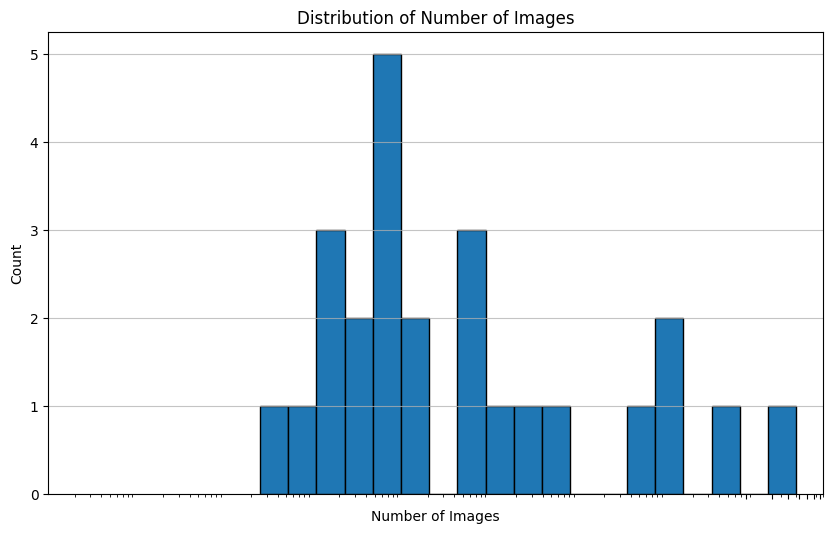

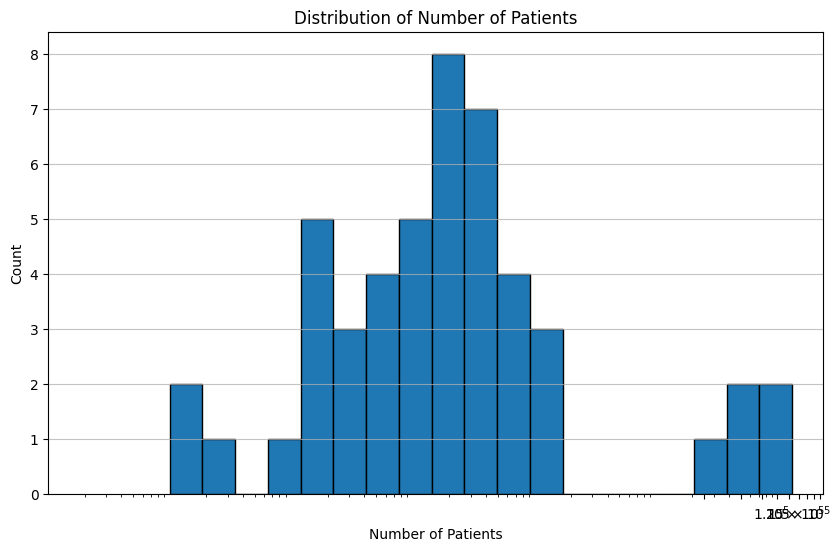

In [7]:
plot_histogram(df, "num_images", title="Distribution of Number of Images", xlabel="Number of Images", ylabel="Count", logx=True)
plot_histogram(df, "num_patients", title="Distribution of Number of Patients", xlabel="Number of Patients", ylabel="Count", logx=True)

Column 'images_per_patient' has 61 / 74 null entries.


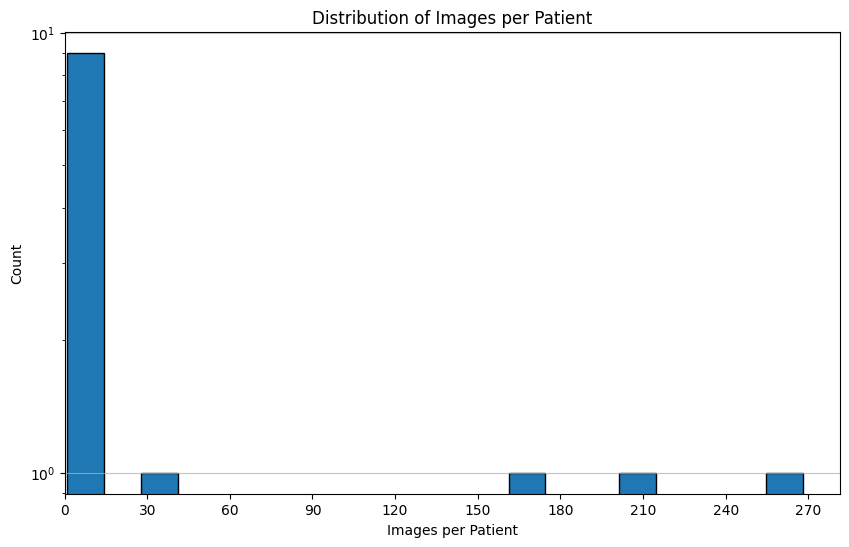

In [8]:
df["images_per_patient"] = df["num_images"] / df["num_patients"]
plot_histogram(df, "images_per_patient", title="Distribution of Images per Patient", xlabel="Images per Patient", ylabel="Count", logy=True)

# Modalities

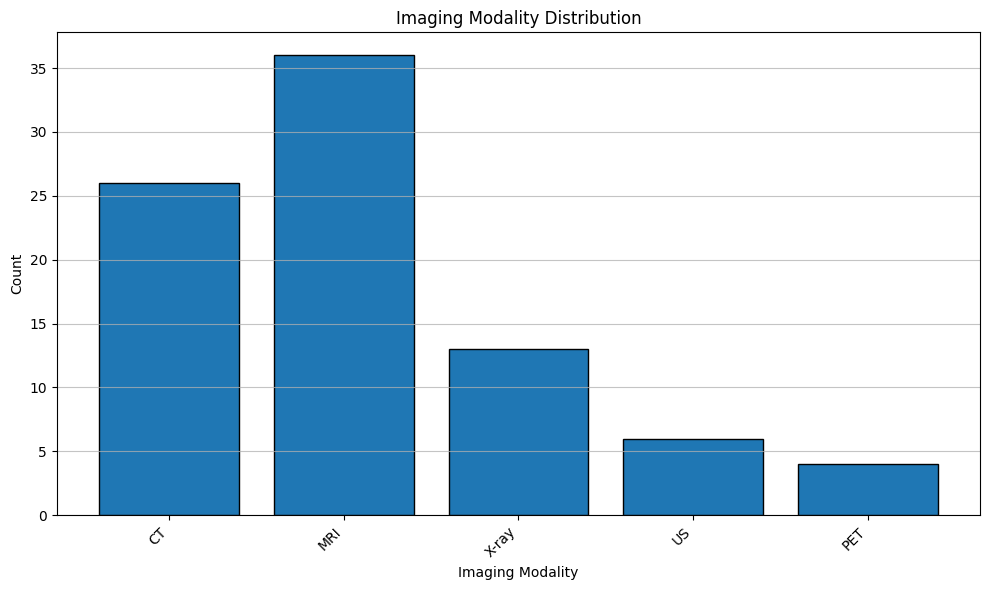

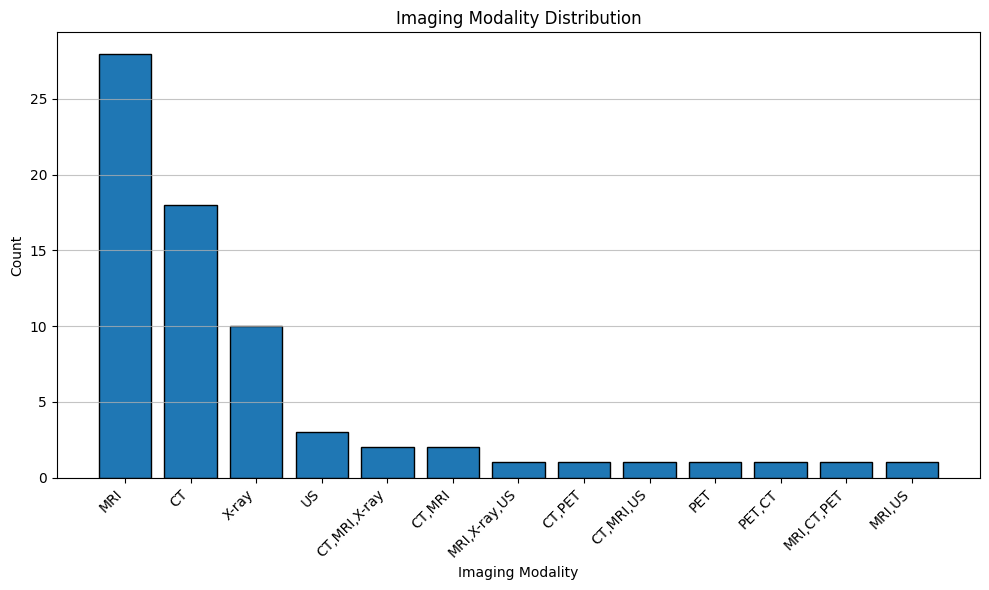

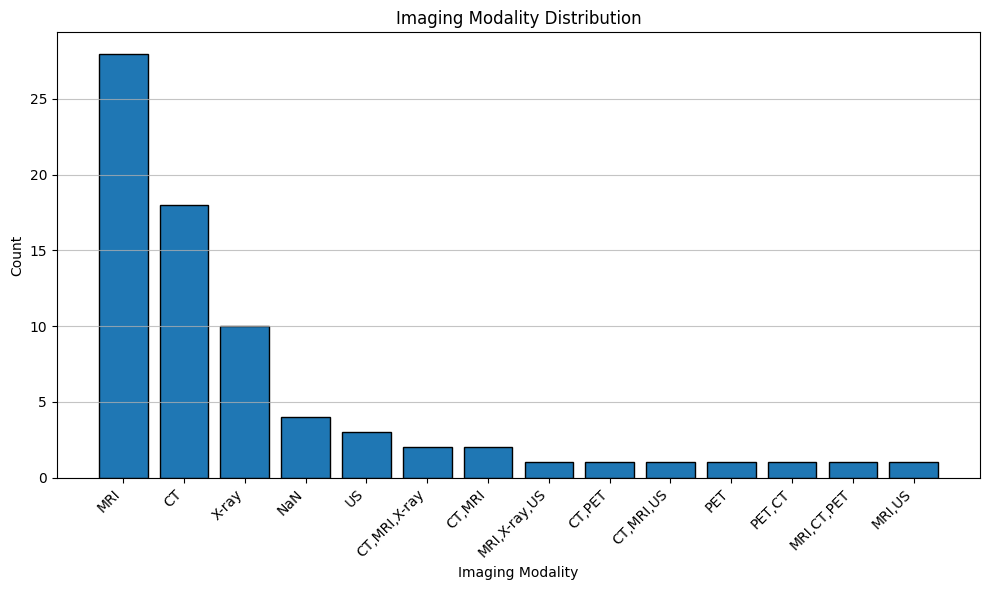

In [9]:
labels, values = count_values_in_comma_joined_column(df, "modalities")
plot_bar_chart(labels, values, xlabel="Imaging Modality", ylabel="Count", title="Imaging Modality Distribution")

counts = df["modalities"].value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Imaging Modality", ylabel="Count", title="Imaging Modality Distribution")

counts = df["modalities"].fillna("NaN").astype(str).value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Imaging Modality", ylabel="Count", title="Imaging Modality Distribution")

# Body regions

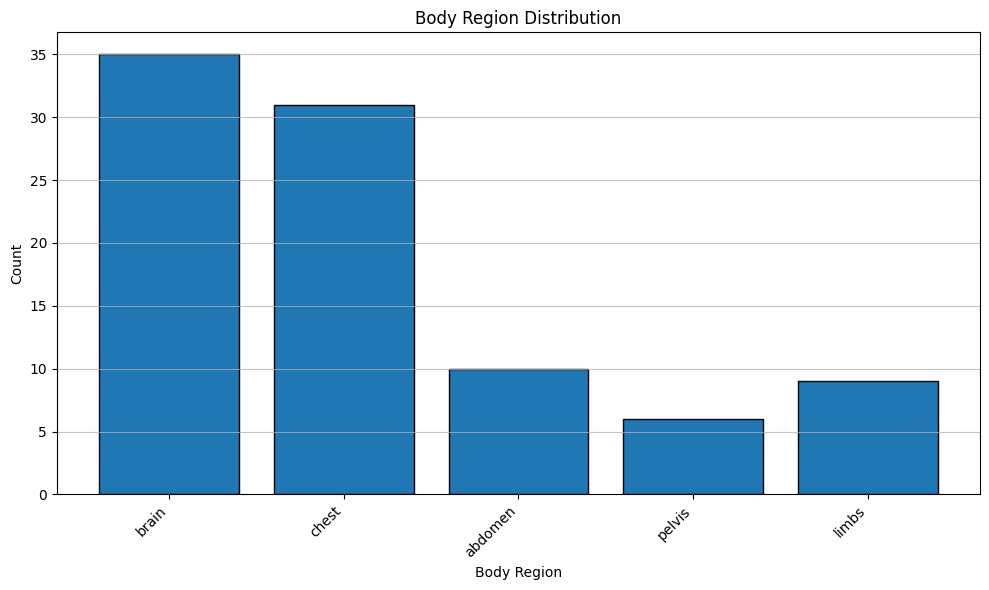

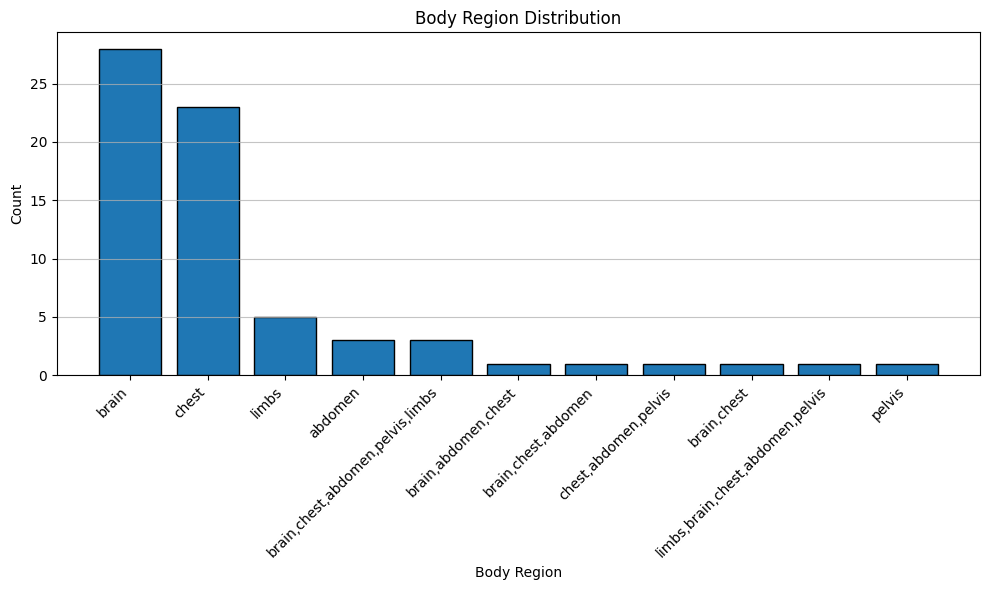

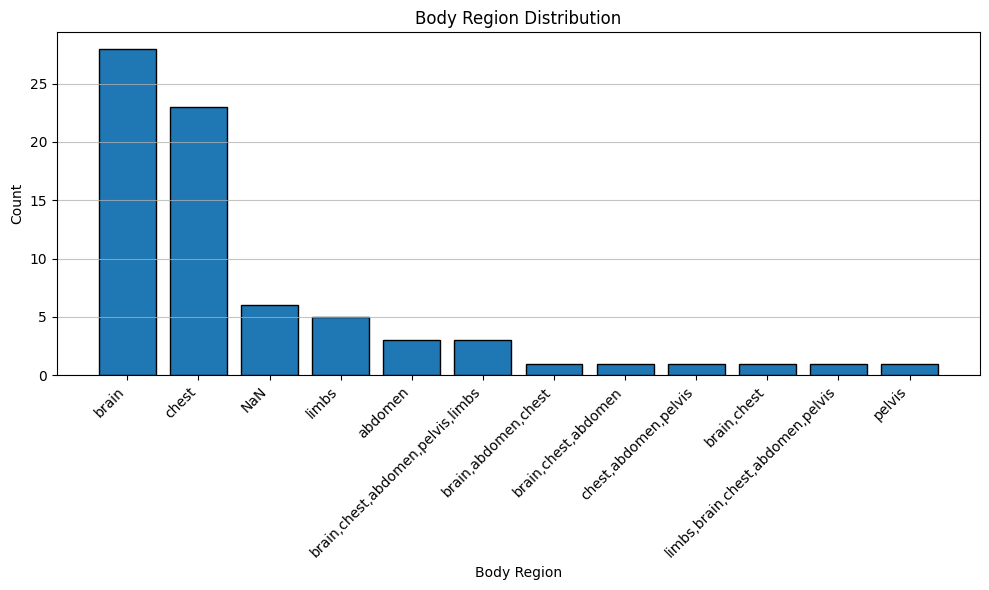

In [10]:
labels, values = count_values_in_comma_joined_column(df, "body_regions")
plot_bar_chart(labels, values, xlabel="Body Region", ylabel="Count", title="Body Region Distribution")

counts = df["body_regions"].value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Body Region", ylabel="Count", title="Body Region Distribution")

counts = df["body_regions"].fillna("NaN").astype(str).value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Body Region", ylabel="Count", title="Body Region Distribution")

# Additional data

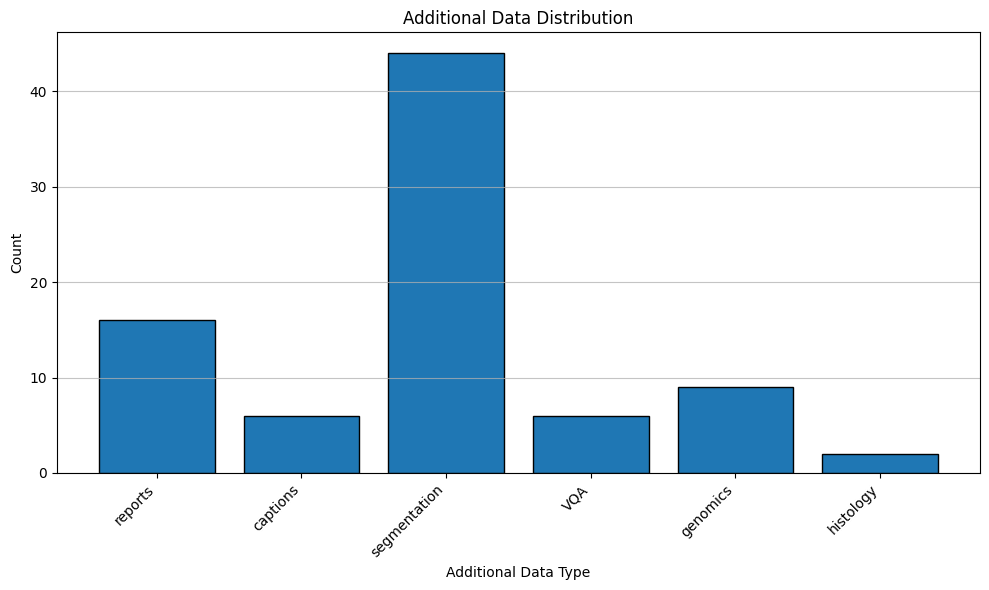

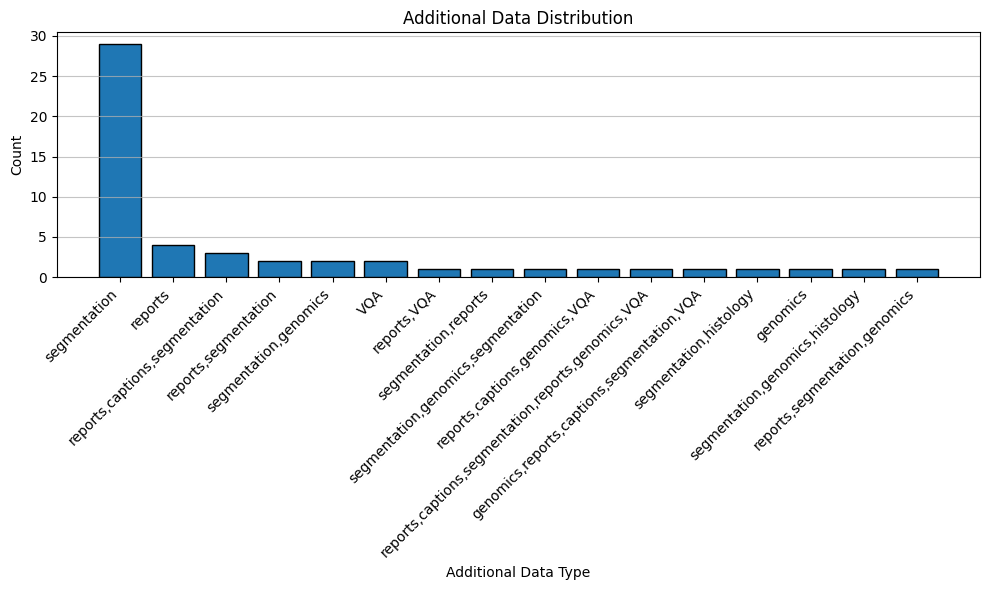

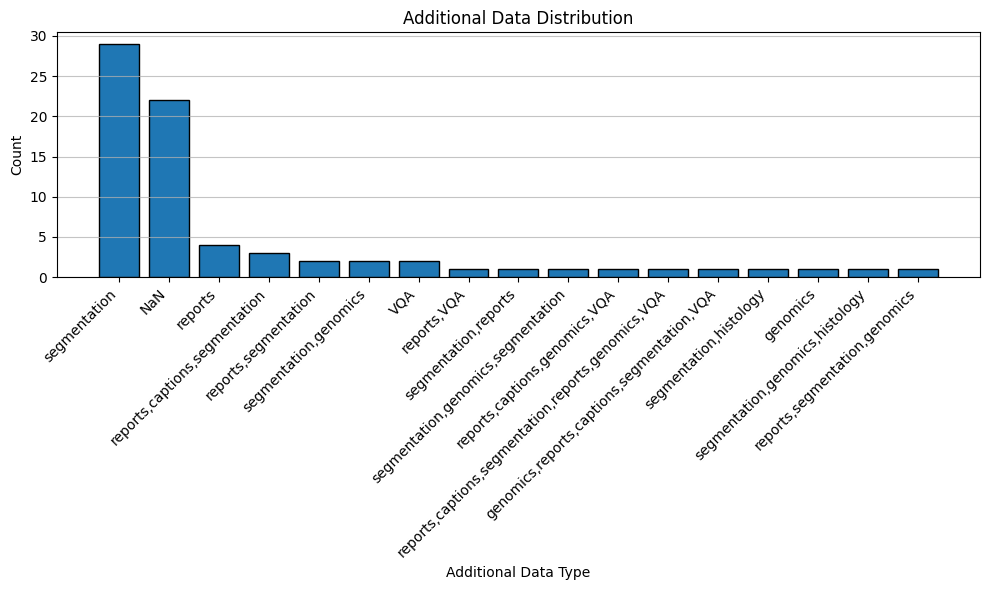

In [11]:
labels, values = count_values_in_comma_joined_column(df, "additional_data")
plot_bar_chart(labels, values, xlabel="Additional Data Type", ylabel="Count", title="Additional Data Distribution")

counts = df["additional_data"].value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Additional Data Type", ylabel="Count", title="Additional Data Distribution")

counts = df["additional_data"].fillna("NaN").astype(str).value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Additional Data Type", ylabel="Count", title="Additional Data Distribution")

## Link works

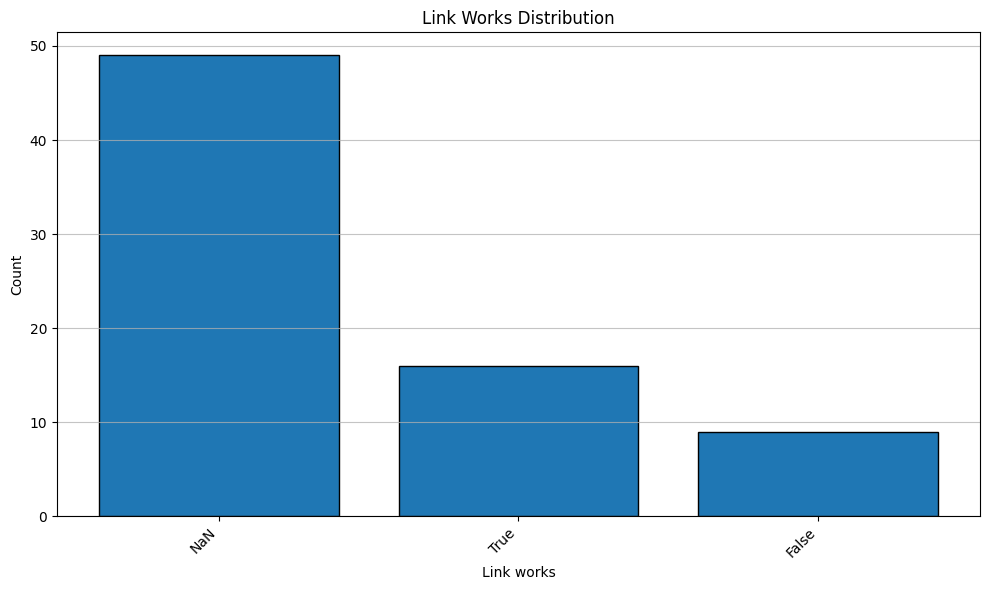

In [12]:
counts = df["link_works"].fillna("NaN").astype(str).value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Link works", ylabel="Count", title="Link Works Distribution")

## MeSH terms and PubMed query matches

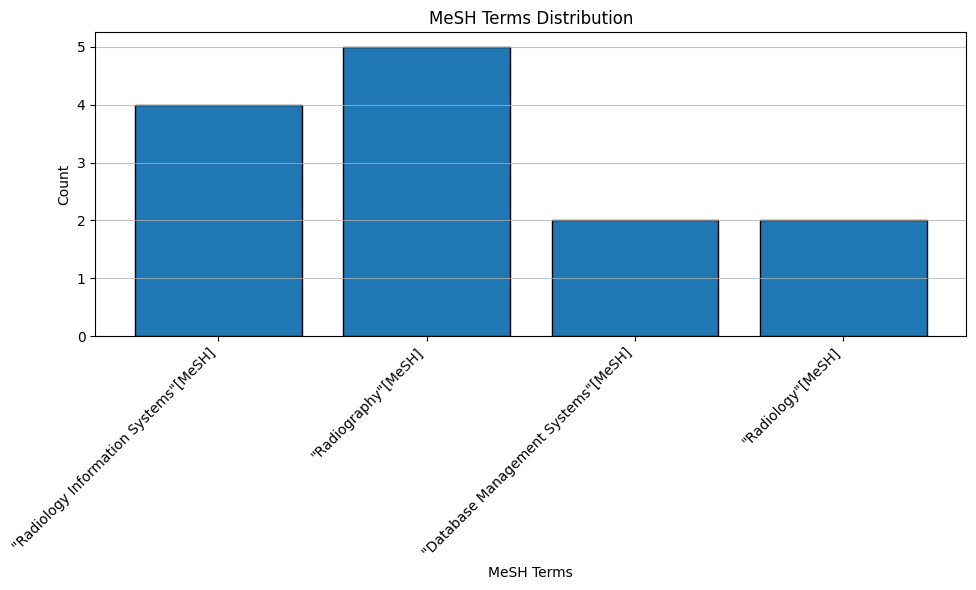

In [13]:
labels, values = count_values_in_comma_joined_column(df, "mesh_terms_in_pubmed_matches")
plot_bar_chart(labels, values, xlabel="MeSH Terms", ylabel="Count", title="MeSH Terms Distribution")

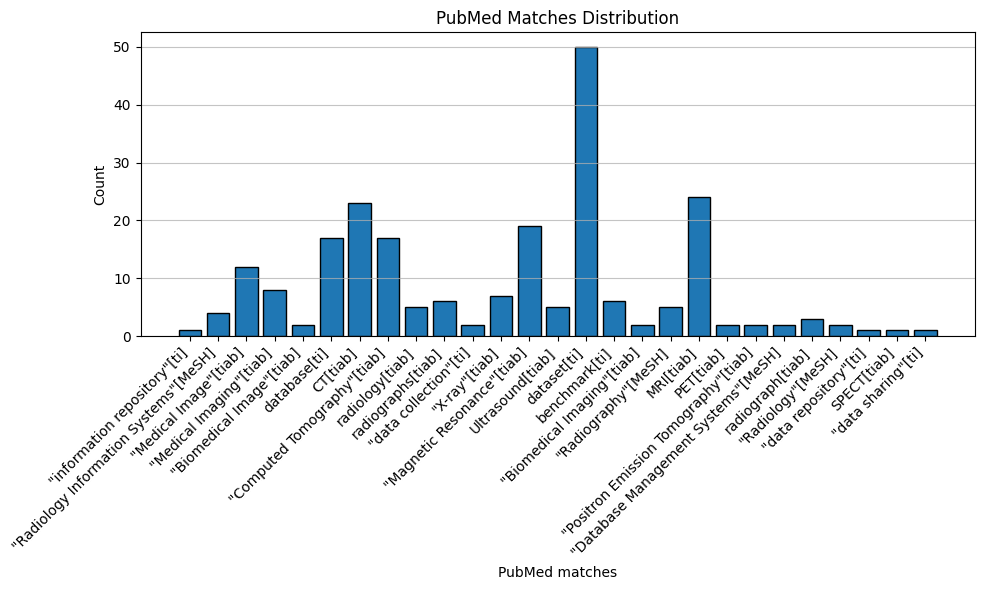

In [14]:
def flatten_and_join(cell):
    if isinstance(cell, str):
        try:
            cell = ast.literal_eval(cell)
        except Exception:
            return ""

    if not isinstance(cell, (list, tuple)):
        return ""

    flat = []
    for sub in cell:
        if isinstance(sub, (list, tuple)):
            flat.extend(sub)
        elif isinstance(sub, str):
            flat.append(sub)

    return ", ".join(flat)


df["pubmed_matches_flattened"] = df["pubmed_matches"].apply(flatten_and_join)

labels, values = count_values_in_comma_joined_column(df, "pubmed_matches_flattened")
plot_bar_chart(labels, values, xlabel="PubMed matches", ylabel="Count", title="PubMed Matches Distribution")

### Compare with unverified data (if available)

/tmp/ipykernel_86856/2413041947.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unverified["pubmed_matches_flattened"] = df_unverified["pubmed_matches"].apply(flatten_and_join)


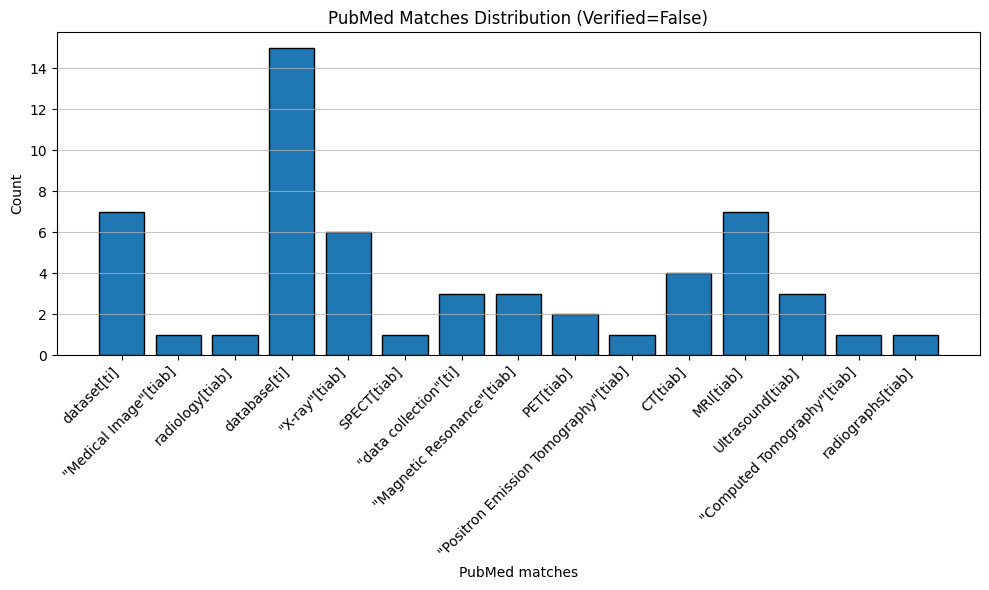

In [15]:
if df_unverified is not None:
    df_unverified["pubmed_matches_flattened"] = df_unverified["pubmed_matches"].apply(flatten_and_join)

    labels, values = count_values_in_comma_joined_column(df_unverified, "pubmed_matches_flattened")
    plot_bar_chart(labels, values, xlabel="PubMed matches", ylabel="Count", title="PubMed Matches Distribution (Verified=False)")

# Citation counts

Column 'paper_year' has 0 / 74 null entries.


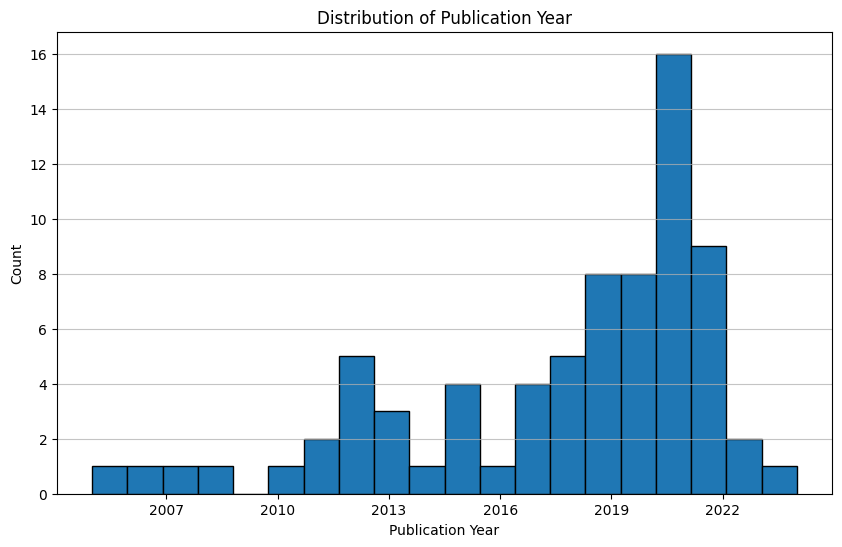

In [16]:
plot_histogram(df, "paper_year", title="Distribution of Publication Year", xlabel="Publication Year", ylabel="Count", xmin=None)

Column 'paper_citation_count' has 0 / 74 null entries.


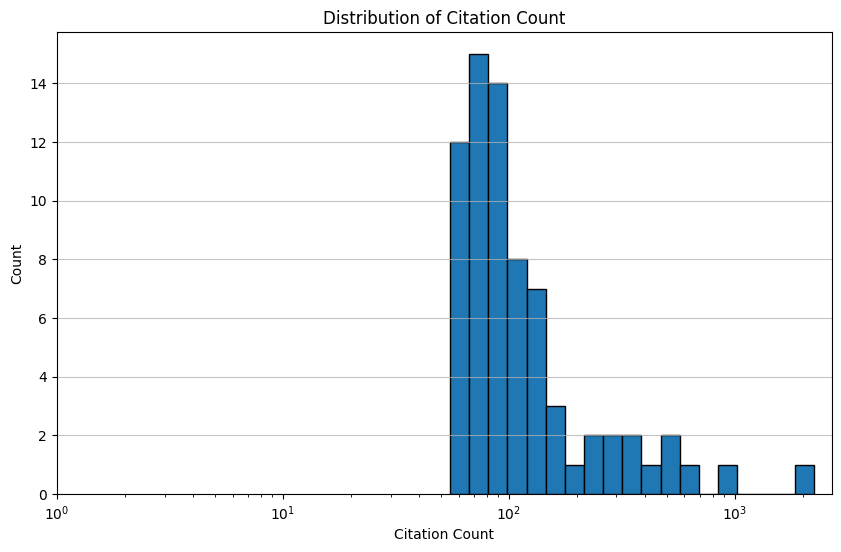

In [17]:
plot_histogram(df, "paper_citation_count", title="Distribution of Citation Count", xlabel="Citation Count", ylabel="Count", xmin=1, logx=True, integer_ticks=False)

# Compare databases

In [20]:
if df_total is not None:
    df = df_total.copy()

In [21]:
### uncomment
# df_path_comparison = os.path.join(base_directory, "data", "radiology_db_sample.csv")

# if not os.path.exists(df_path_comparison):
#     raise FileNotFoundError(f"Data file not found at {df_path_comparison}. Please ensure the file exists.")

# df_comparison = pd.read_csv(df_path_comparison)

# if "verified" in df.columns and "verified" not in df_comparison.columns:
#     df_comparison = df_comparison.merge(df[["paper_title", "verified"]], on="paper_title", how="left")
### uncomment

df_comparison = df.loc[df["dataset_is_available"] == True]  # comment out

In [23]:
compare_dbs(df, df_comparison, merge_col="paper_title")

{'unique_titles_left': 468,
 'unique_titles_right': 331,
 'unique_titles_combined': 468,
 'titles_only_left': 137,
 'titles_only_right': 0,
 'titles_in_both': 331}

Important values to compare:
- verified_left vs. verified_right (recall/sensitivity)
- fraction_verified_left vs. fraction_verified_right (precision/PPV)

In [ ]:
verified_report = None
if "verified" in df.columns and "verified" in df_comparison.columns:
    verified_report = verified_unverified_report(df, df_comparison, merge_col="paper_title", verified_col="verified")

verified_report

{'total_left': 99,
 'total_right': 61,
 'verified_left': 74,
 'verified_right': 55,
 'verified_union': 74,
 'verified_only_left': 19,
 'verified_only_right': 0,
 'verified_intersection': 55,
 'unverified_left': 25,
 'unverified_right': 6,
 'unverified_union': 25,
 'unverified_only_left': 19,
 'unverified_only_right': 0,
 'unverified_intersection': 6,
 'fraction_verified_left': 0.7474747474747475,
 'fraction_verified_right': 0.9016393442622951}

In [36]:
result_df_name = mean_sequence_matcher_in_column(df, df_comparison, column_name="name", merge_col="paper_title")
print(result_df_name.head())

mean_sequence_matcher_in_column for column name
{'mean_ratio': 1.0, 'n_compared': 331}
                                         paper_title  \
0  The Cancer Imaging Archive (TCIA): maintaining...   
1  The Lung Image Database Consortium (LIDC) and ...   
2  MIMIC-CXR, a de-identified publicly available ...   
3  Multiparameter Intelligent Monitoring in Inten...   
4  A Dataset for Breast Cancer Histopathological ...   

                                       name_left  \
0              The Cancer Imaging Archive (TCIA)   
1                             LIDC/IDRI Database   
2                                      MIMIC-CXR   
3                                       MIMIC-II   
4  Breast Cancer Histopathological Image Dataset   

                                      name_right  
0              The Cancer Imaging Archive (TCIA)  
1                             LIDC/IDRI Database  
2                                      MIMIC-CXR  
3                                       MIMIC-II  
4  Breas

In [37]:
result_df_num_images = identical_numbers_in_column(df, df_comparison, column_name="num_images", merge_col="paper_title")
print(result_df_num_images.head())

result_df_num_patients = identical_numbers_in_column(df, df_comparison, column_name="num_patients", merge_col="paper_title")
print(result_df_num_patients.head())

identical_numbers_in_column for column num_images
{'all_identical': True, 'n_compared': 137, 'n_identical': 137, 'identical_fraction': 1.0}
                                         paper_title  num_images_left  \
0  The Cancer Imaging Archive (TCIA): maintaining...        3300000.0   
1  The Lung Image Database Consortium (LIDC) and ...           7371.0   
2  MIMIC-CXR, a de-identified publicly available ...              NaN   
3  Multiparameter Intelligent Monitoring in Inten...              NaN   
4  A Dataset for Breast Cancer Histopathological ...              NaN   

   num_images_right  
0         3300000.0  
1            7371.0  
2               NaN  
3               NaN  
4               NaN  
identical_numbers_in_column for column num_patients
{'all_identical': True, 'n_compared': 202, 'n_identical': 202, 'identical_fraction': 1.0}
                                         paper_title  num_patients_left  \
0  The Cancer Imaging Archive (TCIA): maintaining...                NaN 

In [38]:
result_df_modalities = mean_jaccard_in_column(df, df_comparison, column_name="modalities", merge_col="paper_title")
print(result_df_modalities.head())

result_df_body_regions = mean_jaccard_in_column(df, df_comparison, column_name="body_regions", merge_col="paper_title")
print(result_df_body_regions.head())

result_df_additional_data = mean_jaccard_in_column(df, df_comparison, column_name="additional_data", merge_col="paper_title")
print(result_df_additional_data.head())

mean_jaccard_in_column for column modalities
{'mean_jaccard': 1.0, 'n_compared': 291}
                                         paper_title modalities_left  \
0  The Cancer Imaging Archive (TCIA): maintaining...    CT,MRI,X-ray   
1  The Lung Image Database Consortium (LIDC) and ...              CT   
2  MIMIC-CXR, a de-identified publicly available ...           X-ray   
3  Multiparameter Intelligent Monitoring in Inten...             NaN   
4  A Dataset for Breast Cancer Histopathological ...             NaN   

  modalities_right  
0     CT,MRI,X-ray  
1               CT  
2            X-ray  
3              NaN  
4              NaN  
mean_jaccard_in_column for column body_regions
{'mean_jaccard': 1.0, 'n_compared': 289}
                                         paper_title  \
0  The Cancer Imaging Archive (TCIA): maintaining...   
1  The Lung Image Database Consortium (LIDC) and ...   
2  MIMIC-CXR, a de-identified publicly available ...   
3  Multiparameter Intelligent Monitoring in

# Compare parameter e.g., --num-tries-agent

In [ ]:
# num_tries_agent_values = list(range(1, 10))

# df_path = os.path.join(base_directory, "data", "radiology_db.csv")
# df = pd.read_csv(df_path)
# if "verified" not in df.columns:
#     raise ValueError(f"'verified' column not found in {df_path}. Please ensure the file has this column for comparison.")

# df_dict = {}
# for num_tries_agent in num_tries_agent_values:
#     out_path = os.path.join(base_directory, "data", f"radiology_db_numtries_agent_{num_tries_agent}.csv")
#     if not os.path.exists(out_path):
#         threads = 2
#         cmd = f"python3 {base_directory}/scripts.build_db.py --modality radiology -o {out_path} --num-tries-agent {num_tries_agent} -t {threads}"
#         raise FileNotFoundError(f"Data file not found at {out_path}. Please run the following command to generate it:\n{cmd}\nThen manually verify if results are accurate for each db")
#     df_tmp = pd.read_csv(out_path)
#     if "verified" not in df_tmp.columns:
#         df_tmp = df_tmp.merge(df[["paper_title", "verified"]], on="paper_title", how="left")
#     df_dict[num_tries_agent] = df_tmp

Now download each df, fill in null values in "verified" column with False, and come back here

In [ ]:
# for df in df_dict.values():
#     if df["verified"].isna().any():
#         raise ValueError("Null values found in 'verified' column. Please ensure all entries have a value for 'verified' before comparison.")

In [ ]:
# #!!! untested

# verified_counts = []
# unverified_counts = []
# for num_tries_agent, df_tmp in df_dict.items():
#     verified_counts.append(df_tmp["verified"].sum())
#     unverified_counts.append(df_tmp["verified"].shape[0] - df_tmp["verified"].sum())

# x = np.arange(len(num_tries_agent_values))
# width = 0.35
# plt.figure(figsize=(10, 6))
# plt.bar(x - width/2, verified_counts, width, label='Verified', color='blue', edgecolor='black')
# plt.bar(x + width/2, unverified_counts, width, label='Unverified', color='orange', edgecolor='black')
# plt.xlabel('num_tries_agent')
# plt.ylabel('Count')
# plt.title('Verified vs Unverified Papers by num_tries_agent')
# plt.xticks(x, num_tries_agent_values)
# plt.legend()
# plt.grid(axis='y', alpha=0.75)
# plt.tight_layout()
# plt.show()

In [39]:
!pip list

830.33s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Package                                  Version         Build Editable project location
---------------------------------------- --------------- ----- -----------------------------------------------
accelerate                               1.13.0
ag-ui-protocol                           0.1.14
aiofile                                  3.9.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
anthropic                                0.86.0
anyio                                    4.12.1
apache-tvm-ffi                           0.1.9
argcomplete                              3.6.3
astor                                    0.8.1
asttokens                                3.0.1
async-timeout                            5.0.1
attrs                                    26.1.0
Authlib                                  1